Simulation of phasorplots in a TCSPC image. Intended to see the effects of bleaching, and the difference between 2 component fitting and phasors on the lifetime.

In [1]:
%load_ext watermark

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%watermark -v -p matplotlib,numpy

Python implementation: CPython
Python version       : 3.9.2
IPython version      : 7.20.0

matplotlib: 3.3.4
numpy     : 1.20.1



Steps in the simulation
* Set values for the simulation
* Calculate the resulting lifetimes
* Generate photon arrival times
* Make histogram
* Calculate fft
* Plot first harmonic in a phasorplot

In [3]:
startvalues = {'Baselifetime': 4, 
               'EFretBound': 0.85,
               'EFretUnbound': 0.15,
               'Fraction': 0.5,  # 1 all bound, 0 all unbound
               'Nphotons': 1e6,
               'BinWidth': 0.01,
               'HistogramStop': 25,
               'Harmonic': 1}

In [4]:
# Calculate lifetimes
tau_bound = (1-startvalues['EFretBound'])*startvalues['Baselifetime']
tau_unbound = (1-startvalues['EFretUnbound'])*startvalues['Baselifetime']
print(f'Lifetime of the unboundstate is {tau_unbound:.2}ns')
print(f'Lifetime of the boundstate is {tau_bound:.2}ns')

Lifetime of the unboundstate is 3.4ns
Lifetime of the boundstate is 0.6ns


In [5]:
# 1-Fret efficiency is photons from donor. times the fraction gives the relative nr of photons
rel_bound = (1-startvalues['EFretBound'])*startvalues['Fraction']
rel_unbound = (1-startvalues['EFretUnbound'])*(1-startvalues['Fraction'])

In [6]:
# generate photons
Npht_bound = int(startvalues['Nphotons']*(rel_bound/(rel_bound+rel_unbound)))
Npht_unbound = int(startvalues['Nphotons']-Npht_bound)
rng = np.random.default_rng(seed=1)
photons = np.concatenate((rng.exponential(scale=tau_bound, size=Npht_bound),
                        rng.exponential(scale=tau_unbound, size=Npht_unbound)))
print(f'Generated {Npht_bound} photons from the bound state and {Npht_unbound} photons from the unbound state')

Generated 150000 photons from the bound state and 850000 photons from the unbound state


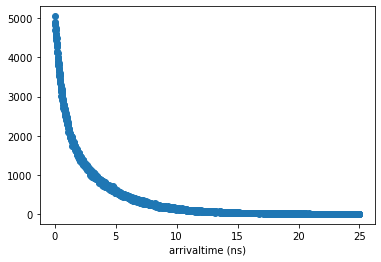

In [7]:
# show distribution
binedges = np.arange(start=0, stop=startvalues['HistogramStop'], step=startvalues['BinWidth'])
hist,binedges = np.histogram(photons,bins=binedges,density=False )

bincenters = binedges[:-1]+np.diff(binedges)/2
hist_L = bincenters[-1]-bincenters[0] # total length of histogram
plt.scatter(bincenters,hist)
plt.xlabel('arrivaltime (ns)');

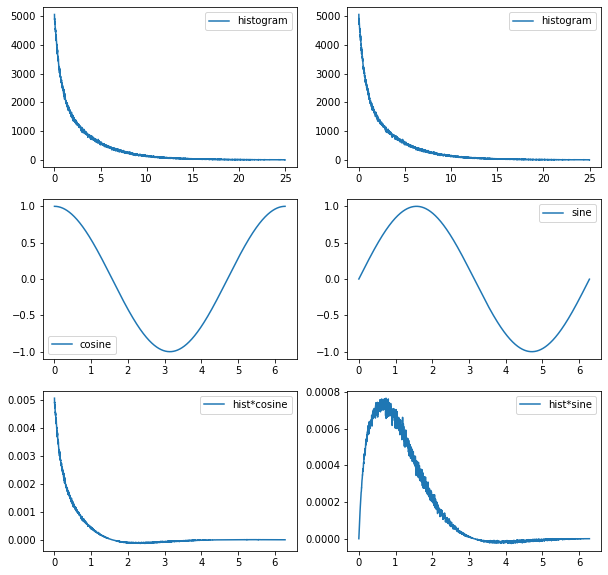

x = sum(hist*cosine) = 0.6386371840359055
y = sum(hist*sine) = 0.4412412342499962


In [12]:
# fourier transform
method='gonio'
if method == 'fft':
    res_fft = np.fft.fft(hist/hist.sum())
    y_ph = -np.imag(res_fft[startvalues['Harmonic']])
    x_ph = np.real(res_fft[startvalues['Harmonic']])
else:  # use normal goniometric functions and show how they look
    phasevec = np.linspace(0,startvalues['Harmonic']*2*np.pi,len(hist),endpoint=False)
    x_ph = (np.cos(phasevec)*(hist/hist.sum())).sum()
    y_ph = (np.sin(phasevec)*(hist/hist.sum())).sum()
    fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(nrows=3, ncols=2, figsize=(10,10))
    ax1.plot(bincenters, hist,label='histogram')
    ax1.legend()
    ax2.plot(bincenters, hist,label='histogram')
    ax2.legend()
    ax3.plot(phasevec, np.cos(phasevec),label='cosine')
    ax3.legend()
    ax4.plot(phasevec, np.sin(phasevec),label='sine')
    ax4.legend()
    ax5.plot(phasevec, np.cos(phasevec)*(hist/hist.sum()),label='hist*cosine')
    ax5.legend()
    ax6.plot(phasevec, np.sin(phasevec)*(hist/hist.sum()),label='hist*sine')
    ax6.legend()
    plt.show()
    print(f'x = sum(hist*cosine) = {x_ph}')
    print(f'y = sum(hist*sine) = {y_ph}')
    

In [9]:
def plotphasor(x,y,hist_L,harmonic,lifetimes,linelifetimes):
    '''helper function to show phasorplots'''
    phase = np.arange(0,np.pi,0.01)
    x_circ = .5+.5*np.cos(phase)
    y_circ = .5*np.sin(phase)
    plt.plot(x_circ,y_circ,'b-')
    plt.plot(x,y,'ro')
    omega = (2*np.pi*harmonic)/(hist_L)
    x = 1/((lifetimes*omega)**2+1)
    y = x*(lifetimes*omega)
    plt.plot(x, y,'.')
    xline = 1/((linelifetimes*omega)**2+1)
    yline = xline*(linelifetimes*omega)
    plt.plot(xline,yline,'k-')

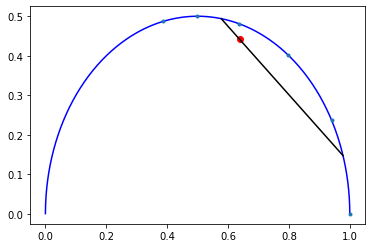

In [10]:
# show location on the phasorplot

lifetimes = np.arange(0,6,1)
plotphasor(x_ph,y_ph,hist_L,startvalues['Harmonic'],lifetimes,np.array((tau_bound, tau_unbound)));